<div align="center">
    
## <font color = #4854E8>**Diabetic Retinopathy Classification Using EfficientNet**</font>
<div>

This notebook focuses on developing a deep learning model to classify diabetic retinopathy severity using a dataset of 35,126 retinal images. Each image is associated with a severity grade ranging from healthy to advanced disease, making it a multi-class classification problem with strong clinical relevance. The workflow covers the full pipeline, starting from data preprocessing and handling class imbalance, to training an EfficientNet-based model and evaluating its performance using metrics suited for ordinal classification. In addition to standard evaluation, the notebook also explores model behaviour through confusion matrices, ROC and precision-recall curves, calibration analysis, and Grad-CAM visualizations. The aim is not only to achieve good predictive performance but also to understand the strengths, limitations, and real-world applicability of the model in detecting and grading diabetic retinopathy.

---


### </font> <font color = #41EA46> **1: Import Libraries**</font>

In [2]:
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as torch_F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm
from scipy.optimize import minimize

from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, 
average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import warnings
warnings.filterwarnings('ignore')

### </font> <font color = #41EA46> **2: Setup & Data Loading**</font>

**Setting the Random Seed:** Before starting the training process, all sources of randomness were fixed to ensure reproducibility. Additionally, CUDA-specific settings were configured to enforce deterministic behavior during GPU execution. This guarantees that the training process is stable and reproducible across multiple runs.

**Loading the Labels Dataset:** The dataset consists of preprocessed retinal images along with a CSV file containing corresponding diabetic retinopathy (DR) severity labels. Each image is mapped to a label ranging from 0 (no DR) to 4 (proliferative DR).

The CSV file also includes a predefined split column, allowing a straightforward separation of the data into training and validation sets without requiring additional splitting logic.

- Training set: 28100 images
- Test set: 7026 image

In [3]:
# Set the Random Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed(42)

# Define the Kaggle paths
LABELS_CSV       = '/kaggle/input/datasets/chooladevapiyasiri/trainlabels-preproccessed/trainLabels_preproccessed.csv'
TRAIN_IMG_DIR   = '/kaggle/input/datasets/chooladevapiyasiri/train-preprocessed/train_preprocessed_384'
UNLABELED_TEST_DIR  =  '/kaggle/input/datasets/chooladevapiyasiri/test-holdout-data/test_preprocessed'
SAVE_PREDICTIONS_PATH   = '/kaggle/working/predictions.csv'
CHECKPOINT_PATH = '/kaggle/working/effnet_checkpoint.pth'
BEST_MODEL_PATH = '/kaggle/working/effnet_best.pth'

In [4]:
# Load the Lablels Dataset
labels_df = pd.read_csv(LABELS_CSV)

train_df  = labels_df[labels_df['split'] == 'train'].reset_index(drop=True)
test_df  = labels_df[labels_df['split'] == 'test'].reset_index(drop=True)

print(f"\nTrain: {len(train_df):,} images | test: {len(test_df):,} images")
print("Train Class Distribution:\n", train_df['level'].value_counts().sort_index())
print("Test Class Distribution:\n",  test_df['level'].value_counts().sort_index())


Train: 28,100 images | test: 7,026 images
Train class distribution:
 level
0    20652
1     1940
2     4244
3      697
4      567
Name: count, dtype: int64
Test class distribution:
 level
0    5158
1     503
2    1048
3     176
4     141
Name: count, dtype: int64


> The class distribution reveals a severe imbalance in the dataset. Grade 0 (no diabetic retinopathy) dominates the training data, accounting for approximately 73% of all samples, while the most critical cases, Grades 3 and 4, together represent less than 5%.
>
> This imbalance reflects real-world clinical screening scenarios, where the majority of patients do not exhibit advanced disease. However, it introduces a major challenge for model training. A naïve model could achieve high overall accuracy simply by predicting the majority class (Grade 0) for most inputs, while failing to correctly identify severe cases. This imbalance will be addressed during model training.
---

### </font> <font color = #41EA46> **3: Model Architecture & Training Pipeline**</font>

**1. Model Overview**

The classification model is built using EfficientNet-B4, a state-of-the-art convolutional neural network pretrained on ImageNet. The original classification head is replaced with a custom fully connected layer to predict five diabetic retinopathy (DR) severity grades (0–4). A transfer learning strategy is applied, where the backbone is initially frozen and later progressively unfrozen to enable domain-specific fine-tuning on retinal images.

**2. Hyperparameter Configuration**

The final training setup was defined based on the best-performing configuration identified during the hyperparameter search phase. The key hyperparameters are as follows:

- Learning Rate (Head): 1e-4
- Learning Rate (Backbone): 1e-5 (after unfreezing)
- Batch Size: 16
- Number of Epochs: 25 (with early stopping)
- Unfreeze Epoch: 4 (after initial warm-up)
- Dropout Rate: 0.5
- Weight Decay: 1e-4
- Focal Loss Gamma: 2.0
- Label Smoothing: 0.05

A Cosine Annealing Learning Rate Scheduler is used to gradually reduce the learning rate during training, improving convergence stability.

**3. Hyperparameter Search Strategy**

To efficiently identify the optimal class weighting strategy, a proxy hyperparameter search was conducted using short 3-epoch training runs. The evaluation metric used was Quadratic Weighted Kappa (QWK), which is more suitable than accuracy due to the ordinal nature of DR grades.

Three configurations were evaluated:

- LowMinority: Equal class weights (baseline)
- HighMinority: Aggressive weighting of minority classes
- BalancedWeighted: Moderate, targeted weighting

The BalancedWeighted configuration ([1.0, 6.0, 4.0, 2.0, 2.0]) achieved the best QWK score and was selected for full training. This configuration places higher emphasis on Grade 1 and Grade 2, which are both underrepresented and visually challenging to distinguish.

**4. Handling Class Imbalance**

Class imbalance is a critical challenge in diabetic retinopathy datasets. This model addresses it through multiple complementary strategies applied at different stages of the pipeline:

**Weighted Random Sampling:** A WeightedRandomSampler is used in the DataLoader to ensure that minority classes are sampled more frequently during training. Each sample is assigned a weight inversely proportional to its class frequency, resulting in more balanced mini-batches.

**Asymmetric Data Augmentation:** Data augmentation is applied differently based on class labels:

- Grade 0 (Healthy): Minimal augmentation (horizontal flip only)
- Grades 1–4 (Diseased): Aggressive augmentation including rotation, flipping, and brightness/contrast adjustments

This approach increases variability in minority classes without unnecessarily modifying the majority class.

**Focal Loss with Class Weights:** Focal Loss is used to prioritize difficult examples by down-weighting easy predictions and focusing training on hard misclassified samples. It is further enhanced with:

- Class weights: Penalizing errors in minority classes more heavily
- Label smoothing: Preventing overconfident predictions

**Mixup Augmentation (Minority Classes Only):** Mixup is selectively applied to diseased classes (Grades 1–4), where pairs of images are blended to create synthetic training samples. This helps the model learn smoother decision boundaries, especially between visually similar classes.

**5. Training Strategy**

**Two-Phase Training**

The training process follows a two-stage transfer learning strategy:

- **Phase 1 (Warm-up):** Only the classification head is trained while the backbone remains frozen. This stabilizes learning and prevents disruption of pretrained features.
- **Phase 2 (Fine-tuning):** The backbone is unfrozen at epoch 4, allowing end-to-end training with discriminative learning rates (lower for backbone, higher for head).

**Mixed Precision Training:** Training is performed using automatic mixed precision (AMP), which improves computational efficiency and reduces memory usage without sacrificing performance.

**Early Stopping:** An early stopping mechanism monitors validation QWK and halts training if no improvement is observed for 7 consecutive epochs. This prevents overfitting and reduces unnecessary computation.

**Checkpointing:** The model state is saved after every epoch, including:

- Model weights
- Optimizer and scheduler states
- Best QWK score
- Early stopping state

The best-performing model (based on QWK) is stored separately for final evaluation.

**6. Evaluation Metric:** The primary metric throughout is Quadratic Weighted Kappa (QWK) rather than plain accuracy. With a 73% grade-0 majority, a model that just predicts "no DR" for every image would hit 73% accuracy while being completely useless clinically. QWK accounts for both the class imbalance and the ordinal nature of the grades; predicting grade 4 when the true label is grade 0 is penalized much more severely than predicting grade 1 for a grade 0 eye.

In [5]:
# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")

# 2. Dataset Class: A custom PyTorch Dataset that loads retinal images from disk applies augmentations during training and normalizes all images.
class DRDataset(Dataset):
    def __init__(self, dataframe, img_dir, is_train=True):
        self.df       = dataframe
        self.img_dir  = img_dir
        self.is_train = is_train
        self.jitter   = transforms.ColorJitter(brightness=0.2, contrast=0.2) # ColorJitter randomly varies brightness and contrast during training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['image']).strip() + ".jpeg"
        label    = int(self.df.iloc[idx]['level'])
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert("RGB")

        if self.is_train:
            # Augmentation Strategy
            # Grade 0 (healthy): only random horizontal flip
            if label == 0:
                if random.random() > 0.5:
                    image = F.hflip(image)
            else:
                # Grades 1–4 (diseased): more aggressive augmentation because these classes are severely underrepresented.
                if random.random() > 0.5:
                    image = F.hflip(image)
                angle = random.choice([0, 90, 120, 180, 270])  # Random rotation
                if angle != 0:
                    image = F.rotate(image, angle)
                image = self.jitter(image)  # Random brightness/contrast shift

        image = F.resize(image, [384, 384])   # Resize to model's expected input
        image = F.to_tensor(image)
        image = F.normalize(image,            # Normalize using ImageNet statistics
                            [0.485, 0.456, 0.406],     # Mean per channel (R, G, B)
                            [0.229, 0.224, 0.225])     # Std  per channel (R, G, B)
        return image, label

# 3. Weighted Random Sampler: Addresses class imbalance at the DataLoader level. Instead of sampling images randomly, this gives minority classes 
# (grades 1–4) a higher probability of being selected each batch.
def make_weighted_sampler(dataframe):
    class_counts   = dataframe['level'].value_counts().sort_index().values
    # Calculate each image's weight, and then rare classes get high weights and common classes get low weights.
    sample_weights = [1.0 / class_counts[lbl] for lbl in dataframe['level'].values]
    sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

# 4. Focal Loss: Standard CrossEntropy treats all misclassifications equally
# Focal Loss adds a (1 - p_t)^gamma factor that DOWN-WEIGHTS easy examples (images the model already classifies confidently) and 
# UP-WEIGHTS hard/misclassified ones.
# Also incorporates:
#   - class_weights: penalizes errors on minority classes more
#   - label_smoothing: prevents overconfident predictions by softening
class FocalLoss(nn.Module):

    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.05):
        super().__init__()
        self.gamma           = gamma
        self.weight          = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Compute standard cross-entropy loss per sample (no reduction)
        ce_loss = torch_F.cross_entropy(
            inputs,  targets, weight=self.weight,  label_smoothing=self.label_smoothing, reduction='none')
        # Compute probability assigned to the correct class
        pt         = torch.exp(-ce_loss)
        # Scale loss — if p_t is high (easy sample), factor ≈ 0 → small loss, if p_t is low (hard sample), factor ≈ 1 → full loss
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# 5. Model Building: Replace the EfficientNet-B4 final classification head with the 5-class head. Initially, the backbone (feature extractor) is Frozen
# and only the new head is trained. Because the backbone already knows how to extract useful visual features, first teach only the head to map those
# features to DR grades.
def build_efficientnet(dropout=0.4):
    # Load pretrained EfficientNet-B4 weights (trained on ImageNet)
    model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
    in_features = model.classifier[1].in_features

    # Replace original 1000-class head with the 5-class DR head
    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=dropout),    # Dropout for regularization (prevents overfitting)
        nn.Linear(in_features, 5)  # 5 output neurons → one per DR grade
    )
    ## Freeze all backbone layers
    for param in model.features.parameters():
        param.requires_grad = False

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model built. Total params: {total_params:,} | "
          f"Trainable (head only): {trainable_params:,}")
    return model

# Called after the head has warmed up. Unfreezes the entire backbone so it can fine-tune on retinal images.
def unfreeze_backbone(model, num_remaining_epochs, lr_backbone=1e-5, lr_head=1e-4):
    
    for param in model.features.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n  Backbone unfrozen! Trainable params: {trainable:,}")
    print(f"   Backbone LR: {lr_backbone} | Head LR: {lr_head}")

    # Create a new optimizer with separate learning rates per layer group
    new_optimizer = torch.optim.AdamW([
        {'params': model.features.parameters(),   'lr': lr_backbone},
        {'params': model.classifier.parameters(), 'lr': lr_head}
    ], weight_decay=1e-4)   # L2 regularization to reduce overfitting
    
    new_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR( new_optimizer, T_max=num_remaining_epochs
    )
    return new_optimizer, new_scheduler

# 6. Early Stopping: # Monitors the test QWK score each epoch. If it doesn't improve for 7 (patience) consecutive epochs, training is halted to prevent
# wasting compute and overfitting to the training set.
class EarlyStopping:
    
    def __init__(self, patience=7):
        self.patience = patience
        self.best     = 0.0
        self.counter  = 0

    def state_dict(self):
        return {'best': self.best, 'counter': self.counter}

    def load_state_dict(self, d):
        self.best    = d['best']
        self.counter = d['counter']

    def step(self, test_kappa) -> bool:
        if test_kappa > self.best:
            self.best    = test_kappa
            self.counter = 0
            return False
        self.counter += 1
        print(f"   No improvement for {self.counter}/{self.patience} epochs "
              f"(best QWK: {self.best:.4f})")
        return self.counter >= self.patience

# 7. Hyperparameter Search  (3 epochs per config): Grid search over class weight configs 
# Instead of training the full model for 25 epochs per config, which is expensive, a fast 3-epoch proxy search was implemented to
# identify the best class weighting strategy. The metric used is QWK.
# Three configs are compared:
# A. LowMinority → no weighting (baseline ablation)
# B. HighMinority → very aggressive minority boosting 
# C. BalancedWeighted → moderate, balanced boost
SEARCH_EPOCHS    = 3
SEARCH_BATCH     = 16
SEARCH_UNFREEZE  = 2   # unfreeze backbone at epoch 2 for fair comparison

# ── Search grid ───────────────────────────────────────────────────
# Config A  [LowMinority]      — ablation: equal weights, no imbalance handling
# Config B  [HighMinority]     — ablation: too aggressive on minorities
# Config C  [BalancedWeighted] — selected config: best QWK balance  ← WINNER
SEARCH_CONFIGS = [
    {   'label':          'LowMinority',
        'class_weights':  [1.0, 1.0, 1.0, 1.0, 1.0],  # Equal weights — no imbalance handling
        'label_smoothing': 0.05,
    },
    {   'label':          'HighMinority',
        'class_weights':  [0.3, 5.0, 4.0, 6.0, 7.0],  # Extreme boosting of rare classes
        'label_smoothing': 0.05,
    },
    {   'label':          'BalancedWeighted',      
        'class_weights':  [1.0, 6.0, 4.0, 2.0, 2.0],  # Moderate, selective boosting, Mild > Moderate boosted most
        'label_smoothing': 0.05,
    },
]

print("Phase 1: Hyperparameter Search (3 epochs per config)")
print(f"Search metric  : QWK (Quadratic Weighted Kappa)\n")

# Build DataLoaders for the search phase
search_test_loader = DataLoader(
    DRDataset(test_df, TRAIN_IMG_DIR, is_train=False),
    batch_size=SEARCH_BATCH, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)
search_train_loader = DataLoader(
    DRDataset(train_df, TRAIN_IMG_DIR, is_train=True),
    batch_size=SEARCH_BATCH,
    sampler=make_weighted_sampler(train_df),
    num_workers=2, pin_memory=True, persistent_workers=True
)

search_results = []

for cfg in SEARCH_CONFIGS:
    print(f"  Testing [{cfg['label']}]")
    print(f"  weights={cfg['class_weights']}  smooth={cfg['label_smoothing']}")

    # Build a fresh model for each config so they start identically
    s_model  = build_efficientnet(dropout=0.4).to(device)
    s_w      = torch.tensor(cfg['class_weights'], dtype=torch.float).to(device)
    s_crit   = FocalLoss(gamma=2.0, weight=s_w, label_smoothing=cfg['label_smoothing'])
    s_opt    = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, s_model.parameters()),
        lr=1e-4, weight_decay=1e-4
    )
    s_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(s_opt, T_max=SEARCH_EPOCHS)
    s_scaler = torch.amp.GradScaler('cuda')
    s_unfrozen = False
    best_score = 0.0
    best_kappa = 0.0

    for ep in range(1, SEARCH_EPOCHS + 1):

        # Unfreeze backbone at epoch 2 for fair fine-tuning comparison
        if ep == SEARCH_UNFREEZE and not s_unfrozen:
            s_opt, s_sched = unfreeze_backbone(
                s_model, num_remaining_epochs=SEARCH_EPOCHS - ep + 1,
                lr_backbone=1e-5, lr_head=1e-4
            )
            s_unfrozen = True

        # Training
        s_model.train()
        for images, labels in search_train_loader:
            images, labels = images.to(device), labels.to(device)
            s_opt.zero_grad()
            with torch.amp.autocast('cuda'):
                out  = s_model(images)
                loss = s_crit(out, labels)
            s_scaler.scale(loss).backward()   # Scaled backward for mixed precision
            s_scaler.step(s_opt)
            s_scaler.update()

        # Evaluation
        s_model.eval()
        ep_preds, ep_labels = [], []
        with torch.no_grad():
            for images, labels in search_test_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    out = s_model(images)
                ep_preds.extend(torch.argmax(out, 1).cpu().numpy())
                ep_labels.extend(labels.cpu().numpy())

        # Compute QWK for this epoch
        ep_kappa = cohen_kappa_score(ep_labels, ep_preds, weights='quadratic')
        score    = ep_kappa

        if score > best_score:
            best_score = score
            best_kappa = ep_kappa

        s_sched.step()
        print(f"    Ep {ep}/{SEARCH_EPOCHS} → "
              f"QWK: {ep_kappa:.4f}")

    search_results.append({ **cfg, 'best_score': best_score, 'best_kappa': best_kappa,  })
    print(f"  [{cfg['label']}] done → "  f"Score: {best_score:.4f}  QWK: {best_kappa:.4f}")

    del s_model, s_opt, s_scaler
    torch.cuda.empty_cache()

# Search Summary
print("Search Results")
sorted_results = sorted(search_results, key=lambda x: x['best_score'], reverse=True)

for r in sorted_results:
    marker = "  ← WINNER" if r['label'] == 'BalancedWeighted' else ""
    print(f"  [{r['label']:26s}]  " f"Score: {r['best_score']:.4f}  " f"QWK: {r['best_kappa']:.4f}{marker}")

# Best config is automatically selected based on highest QWK
best_cfg = sorted_results[0]
print(f"\n  Selected config : [{best_cfg['label']}]")
print(f"  Class weights   : {best_cfg['class_weights']}")
print(f"  Label smoothing : {best_cfg['label_smoothing']}")

# 8. Training Setup: Winner config + Accuracy improvements
# Here set up the actual 25-epoch training run using the best hyperparameter config found.

# Hyperparameters
LEARNING_RATE  = 1e-4
BATCH_SIZE     = 16
NUM_EPOCHS     = 25
UNFREEZE_EPOCH = 4     # Unfreeze backbone after 4 warm-up epochs
DROPOUT        = 0.5   # Slightly higher than search (0.4) for more regularization

# Convert best class weights to GPU tensor
final_weights = torch.tensor( best_cfg['class_weights'], dtype=torch.float).to(device)

# Focal Loss with winner config
criterion = FocalLoss( gamma=2.0, weight=final_weights, label_smoothing=best_cfg['label_smoothing'])

# Build the final model
model     = build_efficientnet(dropout=DROPOUT).to(device)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=1e-4
)
scaler    = torch.amp.GradScaler('cuda')
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=UNFREEZE_EPOCH - 1
)

# Resume logic — pick up from last checkpoint if one exists
start_epoch       = 1
backbone_unfrozen = False
best_kappa        = 0.0
es                = EarlyStopping(patience=7)

if os.path.exists(CHECKPOINT_PATH):
    print("Found existing checkpoint. Resuming...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    start_epoch       = ckpt['epoch'] + 1
    backbone_unfrozen = ckpt.get('backbone_unfrozen', False)
    best_kappa        = ckpt.get('best_kappa', 0.0)
    if 'early_stopping_state' in ckpt:
        es.load_state_dict(ckpt['early_stopping_state'])
    if 'scaler_state_dict' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state_dict'])
    if backbone_unfrozen:
        remaining = NUM_EPOCHS - start_epoch + 1
        optimizer, scheduler = unfreeze_backbone(model, remaining)
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    print(f"Resuming from Epoch {start_epoch} | Best QWK: {best_kappa:.4f}")

# 9. Mixup Augmentation
# Mixup blends two images together, creating smooth transitions between classes, helping the model learn better decision boundaries 
# between visually similar grades (especially grades 1 vs 2, which are frequently confused). 
# Applied only to grades 1–4, leaving grade 0 untouched to avoid accidentally making healthy eyes look diseased.

def mixup_minority(images, labels, alpha=0.3):
    # Find indices of non-zero (diseased) samples in this batch
    minority_mask = (labels > 0).nonzero(as_tuple=True)[0]
    if len(minority_mask) < 2:
        return images, labels         

    # Shuffle minority indices to form pairs
    shuffled = minority_mask[torch.randperm(len(minority_mask))]
    pairs    = min(len(minority_mask) // 2, 4)   # at most 4 pairs per batch

    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)           # keep dominant image above 0.5

    for k in range(pairs):
        i = minority_mask[k].item()
        j = shuffled[k].item()
        # Blend the two images together
        images[i] = lam * images[i] + (1 - lam) * images[j]
        # Labels stay as the dominant image's label (hard mixup)
    return images, labels

# 10. Dataloaders: Full training DataLoaders

train_ds = DRDataset(train_df, TRAIN_IMG_DIR, is_train=True)
test_ds   = DRDataset(test_df,   TRAIN_IMG_DIR, is_train=False)
sampler  = make_weighted_sampler(train_df)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=2,  # 2 parallel workers load images in background
    pin_memory=True,   # Faster CPU to GPU transfer
    persistent_workers=True   # Keep workers alive between epochs
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)
print(f"\nDataLoaders ready — "
      f"Train: {len(train_loader)} batches | Test: {len(test_loader)} batches")

# 11. Training Loop: Full 25-epoch run

train_losses = []
test_losses  = []
test_kappa_scores = []
train_kappa_scores = []  

print("Phase 2: Full Training")
print(f"Config  : [{best_cfg['label']}]")
print(f"Weights : {best_cfg['class_weights']}")
print(f"Extras  : Mixup (minority classes only)\n")

for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # Progressive unfreeze: After 3 warm-up epochs where only the head trains, unfreeze the backbone for end-to-end fine-tuning.
    if epoch == UNFREEZE_EPOCH and not backbone_unfrozen:
        remaining         = NUM_EPOCHS - epoch + 1
        optimizer, scheduler = unfreeze_backbone(
            model, remaining, lr_backbone=1e-5, lr_head=1e-4
        )
        backbone_unfrozen = True

    # Training Phase
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # Apply Mixup to minority samples
        images, labels = mixup_minority(images, labels, alpha=0.3)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Compute epoch-level training metrics
    train_loss  = running_loss / len(train_loader)
    train_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    train_acc   = (np.array(all_preds) == np.array(all_labels)).mean() * 100

    # Evaluation phase
    model.eval()
    test_loss_total = 0.0
    test_preds, test_labels_list = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Test]"):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)
            test_loss_total += loss.item()
            preds = torch.argmax(outputs, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels_list.extend(labels.cpu().numpy())

    test_loss  = test_loss_total / len(test_loader)
    # QWK (Quadratic Weighted Kappa): Unlike accuracy, QWK penalizes predictions proportional to how far off they are predicting 
    # grade 4 for a grade 0 eye is penalized much more than predicting grade 1 for a grade 0 eye.
    test_kappa = cohen_kappa_score(test_labels_list, test_preds, weights='quadratic')

    scheduler.step()

    # Record all metrics for plotting
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_kappa_scores.append(train_kappa)
    test_kappa_scores.append(test_kappa)

    print(f"\n Epoch {epoch}/{NUM_EPOCHS}")
    print(f"   Train → Loss: {train_loss:.4f} | QWK: {train_kappa:.4f}")
    print(f"   Test  → Loss: {test_loss:.4f}   | QWK: {test_kappa:.4f}")
    
    # Checkpoint: save full training state every epoch
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'test_kappa':           test_kappa,
        'best_kappa':           best_kappa,
        'backbone_unfrozen':    backbone_unfrozen,
        'early_stopping_state': es.state_dict(),
    }, CHECKPOINT_PATH)

    # Save a separate copy only when this is the best model so far
    if test_kappa > best_kappa:
        best_kappa = test_kappa
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"   Best model saved (QWK: {best_kappa:.4f})")

    if es.step(test_kappa):
        print(f"\n Early stopping. Best Test QWK: {es.best:.4f}")
        break

print(f"\n Training Complete! Best Test QWK: {best_kappa:.4f}")


Device: cuda
Phase 1: Hyperparameter Search (3 epochs per config)
Search metric  : QWK (Quadratic Weighted Kappa)

  Testing [LowMinority]
  weights=[1.0, 1.0, 1.0, 1.0, 1.0]  smooth=0.05
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 179MB/s] 


Model built. Total params: 17,557,581 | Trainable (head only): 8,965
    Ep 1/3 → QWK: 0.2929

  Backbone unfrozen! Trainable params: 17,557,581
   Backbone LR: 1e-05 | Head LR: 0.0001
    Ep 2/3 → QWK: 0.3086
    Ep 3/3 → QWK: 0.3221
  [LowMinority] done → Score: 0.3221  QWK: 0.3221
  Testing [HighMinority]
  weights=[0.3, 5.0, 4.0, 6.0, 7.0]  smooth=0.05
Model built. Total params: 17,557,581 | Trainable (head only): 8,965
    Ep 1/3 → QWK: 0.1351

  Backbone unfrozen! Trainable params: 17,557,581
   Backbone LR: 1e-05 | Head LR: 0.0001
    Ep 2/3 → QWK: 0.2725
    Ep 3/3 → QWK: 0.2963
  [HighMinority] done → Score: 0.2963  QWK: 0.2963
  Testing [BalancedWeighted]
  weights=[1.0, 6.0, 4.0, 2.0, 2.0]  smooth=0.05
Model built. Total params: 17,557,581 | Trainable (head only): 8,965
    Ep 1/3 → QWK: 0.1676

  Backbone unfrozen! Trainable params: 17,557,581
   Backbone LR: 1e-05 | Head LR: 0.0001
    Ep 2/3 → QWK: 0.4029
    Ep 3/3 → QWK: 0.4330
  [BalancedWeighted] done → Score: 0.4330 

Epoch 1/25 [Test]: 100%|██████████| 440/440 [00:37<00:00, 11.73it/s]



 Epoch 1/25
   Train → Loss: 3.9897 | QWK: 0.1555
   Test  → Loss: 2.6357   | QWK: 0.1647
   Best model saved (QWK: 0.1647)


...


 Epoch 20/25
   Train → Loss: 2.2509 | QWK: 0.8205
   Test  → Loss: 2.1553   | QWK: 0.5662
   No improvement for 5/7 epochs (best QWK: 0.5924)


Epoch 21/25 [Test]: 100%|██████████| 440/440 [00:38<00:00, 11.50it/s]



 Epoch 21/25
   Train → Loss: 2.2723 | QWK: 0.8168
   Test  → Loss: 2.1445   | QWK: 0.5661
   No improvement for 6/7 epochs (best QWK: 0.5924)


Epoch 22/25 [Test]: 100%|██████████| 440/440 [00:37<00:00, 11.71it/s]



 Epoch 22/25
   Train → Loss: 2.2796 | QWK: 0.8158
   Test  → Loss: 2.2021   | QWK: 0.5368
   No improvement for 7/7 epochs (best QWK: 0.5924)

 Early stopping. Best Test QWK: 0.5924

 Training Complete! Best Test QWK: 0.5924


### </font> <font color = #41EA46> **4: Model Evaluation**</font>

**Test-Time Augmentation (TTA):**

Test-Time Augmentation (TTA) is applied during inference to improve prediction robustness. Instead of generating a single prediction per image, the model evaluates multiple transformed versions of the same image and aggregates the results. This approach mirrors the training strategy, where augmentation is used to improve generalization. By exposing the model to different orientations of the same retinal image at inference time, TTA reduces sensitivity to image alignment and helps produce more stable and reliable predictions.

In this implementation, four valid transformations are used:

- Original image
- Horizontal flip
- Vertical flip
- 90° rotation

For each input image, predictions are generated for all four augmented views. The model outputs are converted into probability distributions using the softmax function. These probabilities are then averaged across all views to produce a final prediction. Averaging is performed on probabilities rather than raw logits to ensure consistency, as probabilities are normalized within the range [0,1], whereas logits are not directly comparable across transformations.

####  <font color = blue> **I. Classification Report** </font>

A classification report is generated, providing precision, recall, and F1-score for each class. This provides a more detailed breakdown of how the model performs across different severity levels.

In [6]:
print("Final Evaluation with Test-Time Augmentation (TTA)")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

def predict_with_tta(model, images, device):
    # Define the 4 augmented views of each batch
    views = [ images,                                # Original View
        torch.flip(images, dims=[-1]),               # Horizontal Flip
        torch.flip(images, dims=[-2]),               # Vertical Flip
        torch.rot90(images, k=1, dims=[-2, -1]),     # 90-Degree Rotation
    ]
    probs = []
    # Disable gradient computation for faster inference
    with torch.no_grad():
        for v in views:
            # Use mixed precision for faster computation on GPU
            with torch.amp.autocast('cuda'):
                logits = model(v.to(device))
            # Convert logits to probabilities using softmax    
            probs.append(torch.softmax(logits, dim=1))
            
    return torch.stack(probs).mean(0)   # [B, 5]

tta_preds  = []
tta_labels = []
tta_probs  = [] 

for images, labels in tqdm(test_loader, desc="TTA Eval"):
    # Get averaged probabilities using TTA
    avg_probs = predict_with_tta(model, images, device)
    # Select the class with highest probability
    preds     = avg_probs.argmax(dim=1)
    
    tta_preds.extend(preds.cpu().numpy())
    tta_labels.extend(labels.numpy())
    tta_probs.extend(avg_probs.cpu().numpy())

# Calculate evaluation metrics QWK score, Accuracy %
tta_kappa = cohen_kappa_score(tta_labels, tta_preds, weights='quadratic')
tta_acc   = (np.array(tta_preds) == np.array(tta_labels)).mean() * 100

print(f"\n Final Results (with TTA):")
print(f"   QWK      : {tta_kappa:.4f}")
print(f"   Accuracy : {tta_acc:.1f}%") 
print(f"   MCC      : {matthews_corrcoef(tta_labels, tta_preds):.4f}") 

print(f"\nClassification Report:")
print(classification_report(tta_labels, tta_preds,
    target_names=['0: Healthy', '1: Mild', '2: Moderate','3: Severe', '4: Proliferative'], digits=2))

# Map for downstream plots
all_labels_eval = tta_labels
all_preds_eval  = tta_preds
all_probs       = tta_probs

Final Evaluation with Test-Time Augmentation (TTA)


TTA Eval: 100%|██████████| 440/440 [02:27<00:00,  2.98it/s]


 Final Results (with TTA):
   QWK      : 0.6111
   Accuracy : 73.7%
   MCC      : 0.3328

Classification Report:
                  precision    recall  f1-score   support

      0: Healthy       0.82      0.91      0.86      5158
         1: Mild       0.13      0.11      0.12       503
     2: Moderate       0.58      0.21      0.31      1048
       3: Severe       0.40      0.57      0.47       176
4: Proliferative       0.41      0.74      0.52       141

        accuracy                           0.74      7026
       macro avg       0.47      0.51      0.46      7026
    weighted avg       0.72      0.74      0.71      7026



> Interpretation:
>
> **Overall Performance:**
>
> - **Accuracy:** EfficientNet-B4 achieved an accuracy of 73.7%, indicating that nearly three-quarters of the test samples were correctly classified. However, accuracy alone does not fully capture performance in this task due to class imbalance.
>
> - **Quadratic Weighted Kappa (QWK):** A score of 0.6111 suggests a moderate level of agreement between predicted and actual labels, which is particularly important for ordinal classification problems like diabetic retinopathy grading. This indicates that while the model is reasonably aligned with true severity levels, there is still room for improvement in distinguishing adjacent classes.
> 
> - **Matthews Correlation Coefficient (MCC):** EfficientNet-B4 achieved an MCC of 0.3328 reflects a modest overall correlation between predictions and true labels. This relatively lower value highlights the challenges posed by imbalanced class distributions and misclassifications in minority classes
>
---

####  <font color = blue> **II. Confusion Matrix** </font>

Confusion matrices were generated using both raw counts and normalized percentages to better understand how the model performs across different classes. This helps highlight not only where the model is correct, but also where it tends to make misclassifications.

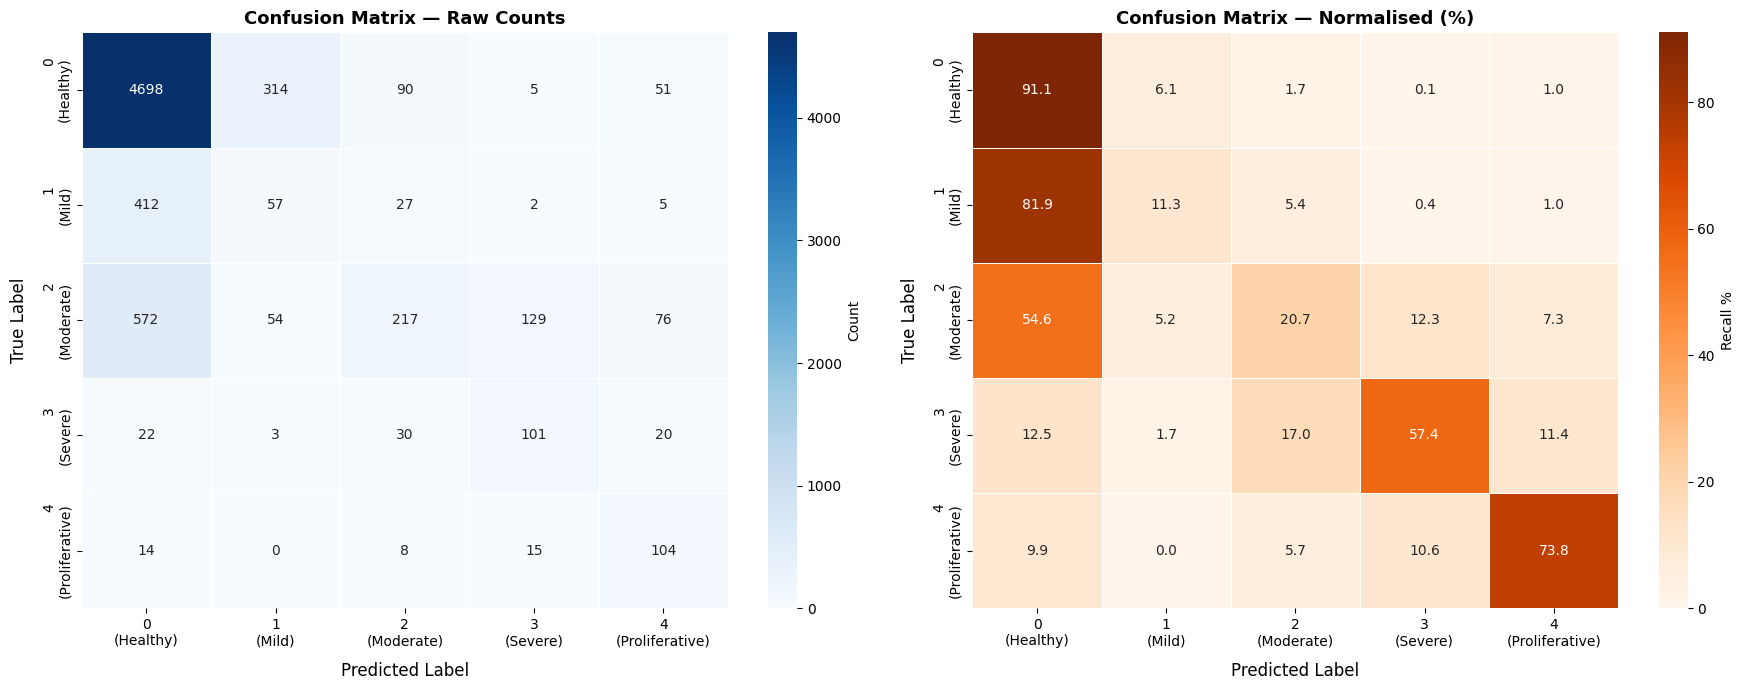

In [7]:
def plot_confusion_matrices(all_labels_eval, all_preds_eval):

    class_names = ['0\n(Healthy)','1\n(Mild)','2\n(Moderate)','3\n(Severe)','4\n(Proliferative)']

    # Compute confusion matrix (raw counts)
    cm      = confusion_matrix(all_labels_eval, all_preds_eval)
    # Normalize by row to get percentage (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row %

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    # Raw Counts Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Count'}, ax=axes[0])
    
    axes[0].set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    axes[0].set_ylabel('True Label',      fontsize=12, labelpad=10)
    axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')

    #  Normalised % Matrix
    sns.heatmap( cm_norm, annot=True, fmt='.1f', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Recall %'}, ax=axes[1])
    
    axes[1].set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    axes[1].set_ylabel('True Label',      fontsize=12, labelpad=10)
    axes[1].set_title('Confusion Matrix — Normalised (%)', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(all_labels_eval, all_preds_eval);

> Interpretation:
>
> **Class by Class Analysis:**
>
> - **Class 0 – Healthy:** Shows strong performance with precision 0.82, recall 0.91, and F1-score 0.86. While most healthy cases are correctly identified, a significant number of diseased samples are still misclassified as healthy.
>   
> - **Class 1 – Mild:** Represents the the weakest class, with precision 0.13, recall 0.11, and F1-score 0.12. The model misses most mild cases, indicating difficulty in detecting early-stage disease.
>   
> - **Class 2 – Moderate:** Moderate performance with precision 0.58, recall 0.21, and F1-score 0.31. Although predictions are somewhat reliable when made, many moderate cases are not detected.
>   
> - **Class 3 – Severe:** Shows improved detection with precision 0.40, recall 0.57, and F1-score 0.47. The model captures more severe cases but still produces some false positives.
> 
> - **Class 4 – Proliferative:** Despite the smallest sample size, this class performs relatively well with precision 0.41, recall 0.74, and F1-score 0.52, indicating good detection of advanced disease stages.
--- 

####  <font color = blue> **III. ROC and Precision-Recall Curve Analysis** </font>

ROC and Precision–Recall (PR) curves were generated using the predicted probabilities and true labels to evaluate the model beyond accuracy-based metrics. This helps assess how well the model separates classes and handles imbalanced data. While ROC-AUC measures overall separability between healthy and diseased cases, the Precision–Recall curves give deeper insight into how well each severity class is handled, particularly in the presence of class imbalance.

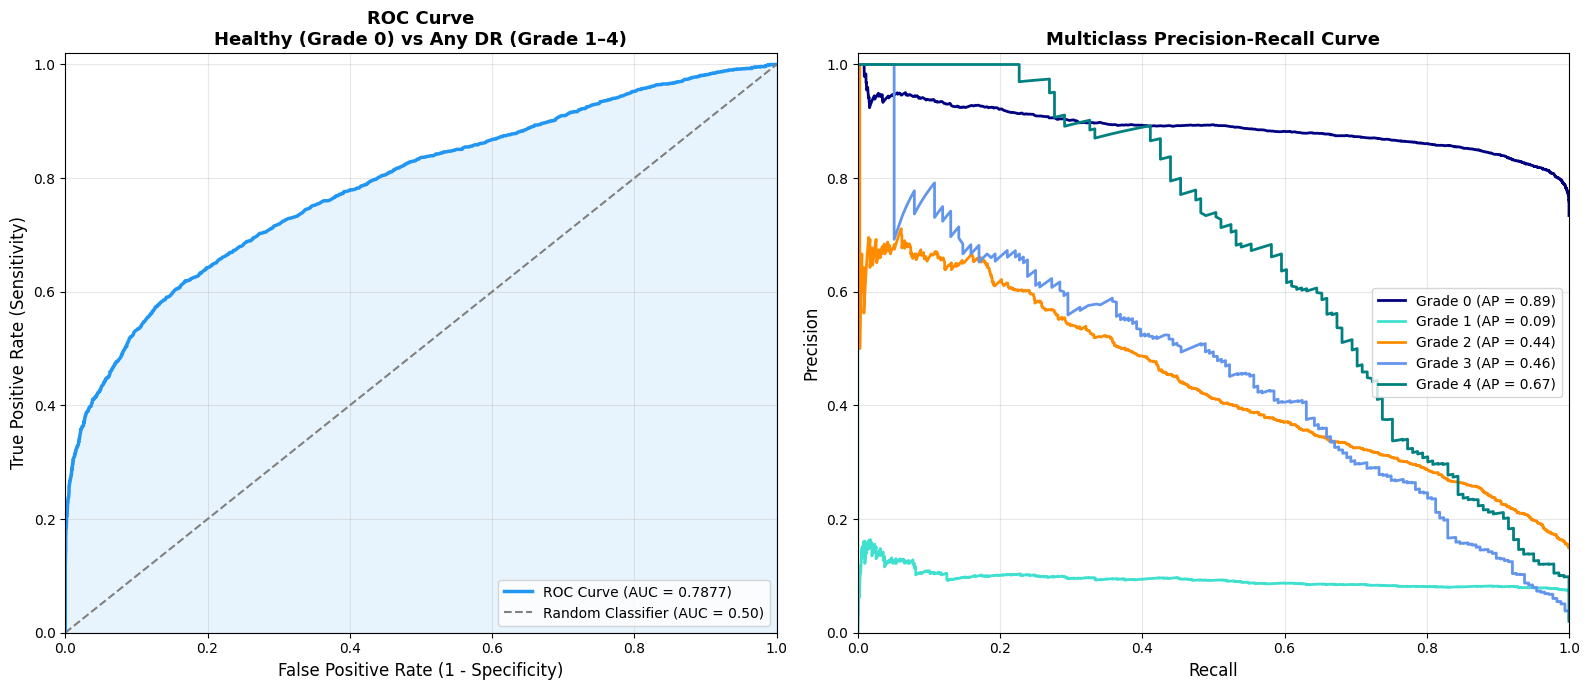

ROC-AUC (Healthy vs Any DR): 0.7877
Average Precision — Grade 0: 0.8880
Average Precision — Grade 1: 0.0938
Average Precision — Grade 2: 0.4382
Average Precision — Grade 3: 0.4638
Average Precision — Grade 4: 0.6700


In [8]:
def plot_roc_and_pr_curves(all_labels_eval, all_probs):

    all_probs = np.array(all_probs)

    # Binary classification setup (Healthy vs Any DR)
    # Convert labels: 0 = Healthy, 1–4 = Diseased
    binary_true  = (np.array(all_labels_eval) > 0).astype(int)

    # Sum probabilities of all disease classes to get "Disease score"
    binary_score = all_probs[:, 1:].sum(axis=1)

    # ROC Curve computation
    # FPR = false positive rate, TPR = true positive rate
    fpr, tpr, _ = roc_curve(binary_true, binary_score)
    # Area under ROC curve
    roc_auc     = auc(fpr, tpr)

    # Multi-class one-vs-rest setup for PR curves
    # Convert labels into one-hot encoded format
    Y         = label_binarize(all_labels_eval, classes=[0, 1, 2, 3, 4])
    n_classes = Y.shape[1]
    colors    = ['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal']

    pr_data = []

    # Compute Precision-Recall curve for each class
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(Y[:, i], all_probs[:, i])
        ap = average_precision_score(Y[:, i], all_probs[:, i])
        pr_data.append((precision, recall, ap))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # ROC Curve Plot (Binary)
    ax1.plot(fpr, tpr, color='#2196F3', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax1.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
    ax1.plot([0, 1], [0, 1],  color='gray', linestyle='--', linewidth=1.5,  label='Random Classifier (AUC = 0.50)')
    ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax1.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=12)
    ax1.set_title('ROC Curve\nHealthy (Grade 0) vs Any DR (Grade 1–4)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1.02])

    # Multiclass PR Curve
    for i, (precision, recall, ap) in enumerate(pr_data):
        ax2.plot(recall, precision, color=colors[i], linewidth=2, label=f'Grade {i} (AP = {ap:.2f})')
        
    ax2.set_xlabel('Recall',    fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Multiclass Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1.02])

    plt.tight_layout()
    plt.show()

    # Print evaluation summary
    print(f"ROC-AUC (Healthy vs Any DR): {roc_auc:.4f}")
    # Print Average Precision for each class
    for i, (_, _, ap) in enumerate(pr_data):
        print(f"Average Precision — Grade {i}: {ap:.4f}")

plot_roc_and_pr_curves(all_labels_eval, all_probs);

> Interpretation:
> 
> **ROC Curve Analysis**
>
> - The model achieved an AUC of 0.7877, which indicates a reasonable ability to separate healthy from diseased cases.
>
> - The curve rises quickly at lower false positive rates but begins to flatten as sensitivity increases. This suggests that the model is effective at identifying clear, easily distinguishable cases of disease. However, as it attempts to capture more subtle cases, the number of false positives increases noticeably.
>
> **Precision–Recall Analysis**
>
> - **Grade 0 (Healthy):** AP = 0.89
>
> The model demonstrates strong and consistent performance for healthy cases, maintaining high precision across recall levels. This indicates reliable identification of non-diseased images.
>
> - **Grade 1 (Mild):** AP = 0.09
> 
> This is the weakest class by a large margin. The very low AP indicates that the model struggles significantly to detect early-stage diabetic retinopathy and often confuses it with healthy cases.
>
> - **Grade 2 (Moderate):** AP ≈ 0.44
>
> Performance shows moderate improvement, but remains limited. A significant number of moderate cases are still misclassified, often overlapping with adjacent grades.
>
> - **Grade 3 (Severe):** AP ≈ 0.46
> 
> The model demonstrates moderate performance, but precision declines as recall increases, indicating inconsistent predictions and difficulty in clearly separating this class from neighbouring severity levels.
>
> - **Grade 4 (Proliferative):** AP = 0.67
> 
> The model performs relatively well on severe disease cases. When it predicts proliferative DR, it is usually correct, showing strong recognition of advanced disease patterns.
>
> **The ROC-AUC (0.7877) gives a moderately positive overall impression, but the PR results reveal a much weaker performance on minority and clinically important early-stage classes.**
--- 

####  <font color = blue> **IV. Loss and QWK Curve Analysis** </font>

This analysis provides a clear view of model learning behaviour over time. Loss curves show optimization progress, while QWK curves reflect true predictive quality. Together, they help identify the most effective training stage and ensure the final model is selected based on validation performance rather than the last epoch.

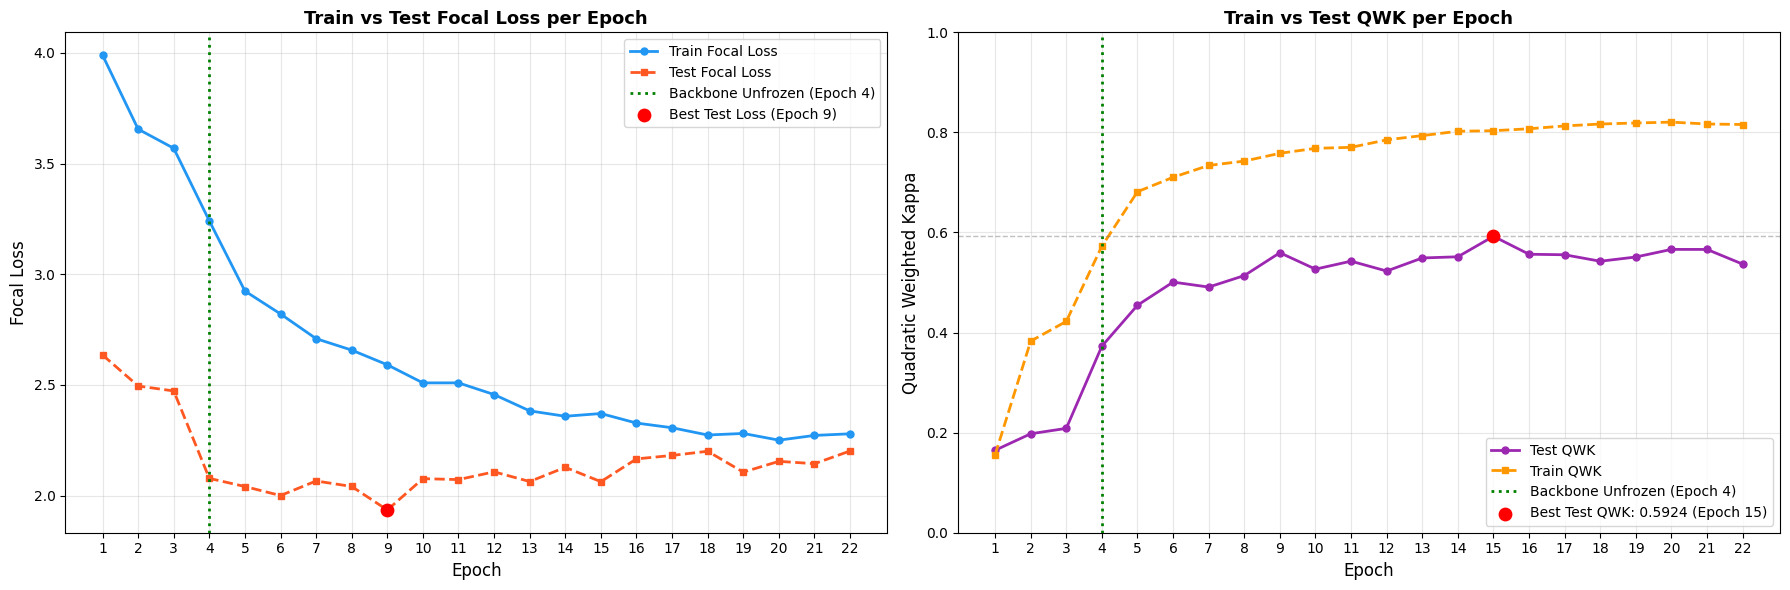

In [9]:
def plot_training_curves(train_losses, test_losses, train_kappa_scores, test_kappa_scores, unfreeze_epoch):

    epochs_ran = list(range(1, len(train_losses) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss Curves
    # Plot training focal loss
    ax1.plot(epochs_ran, train_losses, marker='o', linewidth=2, markersize=5, color='#2196F3', label='Train Focal Loss')
    # Plot test/validation focal loss
    ax1.plot(epochs_ran, test_losses, marker='s', linewidth=2, markersize=5, color='#FF5722', linestyle='--', label='Test Focal Loss')
    
    # Mark the epoch where backbone was unfrozen (fine-tuning started)
    if unfreeze_epoch <= len(epochs_ran):
        ax1.axvline(unfreeze_epoch, color='green', linestyle=':', linewidth=2, label=f'Backbone Unfrozen (Epoch {unfreeze_epoch})')
    
    # Identify best test loss epoch (minimum loss)
    best_loss_ep = int(np.argmin(test_losses)) + 1
    # Highlight best test loss point
    ax1.scatter(best_loss_ep, min(test_losses), color='red', zorder=5, s=80, label=f'Best Test Loss (Epoch {best_loss_ep})')
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Focal Loss', fontsize=12)
    ax1.set_title('Train vs Test Focal Loss per Epoch', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs_ran)

    # Plot QWK Curves
    # Plot test QWK scores
    ax2.plot(epochs_ran, test_kappa_scores, marker='o', linewidth=2, markersize=5, color='#9C27B0', label='Test QWK')
    # Plot training QWK scores
    ax2.plot(epochs_ran, train_kappa_scores, marker='s', linewidth=2, markersize=5, color='#FF9800', linestyle='--', label='Train QWK')

    # Mark backbone unfreeze point for QWK plot
    if unfreeze_epoch <= len(epochs_ran):
        ax2.axvline(unfreeze_epoch, color='green', linestyle=':', linewidth=2,  label=f'Backbone Unfrozen (Epoch {unfreeze_epoch})')

    # Identify best test QWK epoch (maximum QWK)
    best_kappa_ep = int(np.argmax(test_kappa_scores)) + 1
    best_kappa_test = max(test_kappa_scores)

    # Highlight best QWK point
    ax2.scatter(best_kappa_ep, best_kappa_test,  color='red', zorder=5, s=80, label=f'Best Test QWK: {best_kappa_test:.4f} (Epoch {best_kappa_ep})')

    ax2.axhline(best_kappa_test, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Quadratic Weighted Kappa', fontsize=12)
    ax2.set_title('Train vs Test QWK per Epoch', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    ax2.set_xticks(epochs_ran)

    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses, test_losses, train_kappa_scores, test_kappa_scores, UNFREEZE_EPOCH);

> Interpretation:
>
> **Loss Curve Analysis:**
>
> - A clear change can be observed at Epoch 4, where the backbone is unfrozen. Before this point, the loss decreases gradually, as only the classification head is being trained. After unfreezing, the decline becomes steeper, indicating that the deeper layers are now being fine-tuned. The model reaches its lowest test loss relatively early, around Epoch 9, showing fast convergence.
> 
> **QWK Curve Analysis:**
>
> - The QWK stabilizes around 0.59. There is a noticeable gap between training and testing performance, with training QWK exceeding 0.8 while test QWK remains significantly lower. This indicates overfitting, where the model learns the training data very well but struggles to generalize.
>
> - Unfreezing the backbone at Epoch 4 plays a crucial role in improving performance. Without this step, the model would likely have plateaued at a lower level.
> 
---

####  <font color = blue> **V. Grad-CAM Analysis** </font>

Grad-CAM visualizations represent where the model focuses when making correct and incorrect predictions across all diabetic retinopathy grades. Areas shown in red and yellow indicate high importance, while blue regions have little influence on the prediction.

Running inference on test set for error analysis...


Scanning test set:  36%|███▌      | 2509/7026 [00:10<00:18, 242.50it/s]


  Early exit at image 2509 — all grades have 5 correct + 5 incorrect candidates.
  Scanned 409 images total.
  Correct   candidates per grade: {0: 130, 1: 5, 2: 5, 3: 12, 4: 18}
  Incorrect candidates per grade: {0: 5, 1: 181, 2: 43, 3: 5, 4: 5}


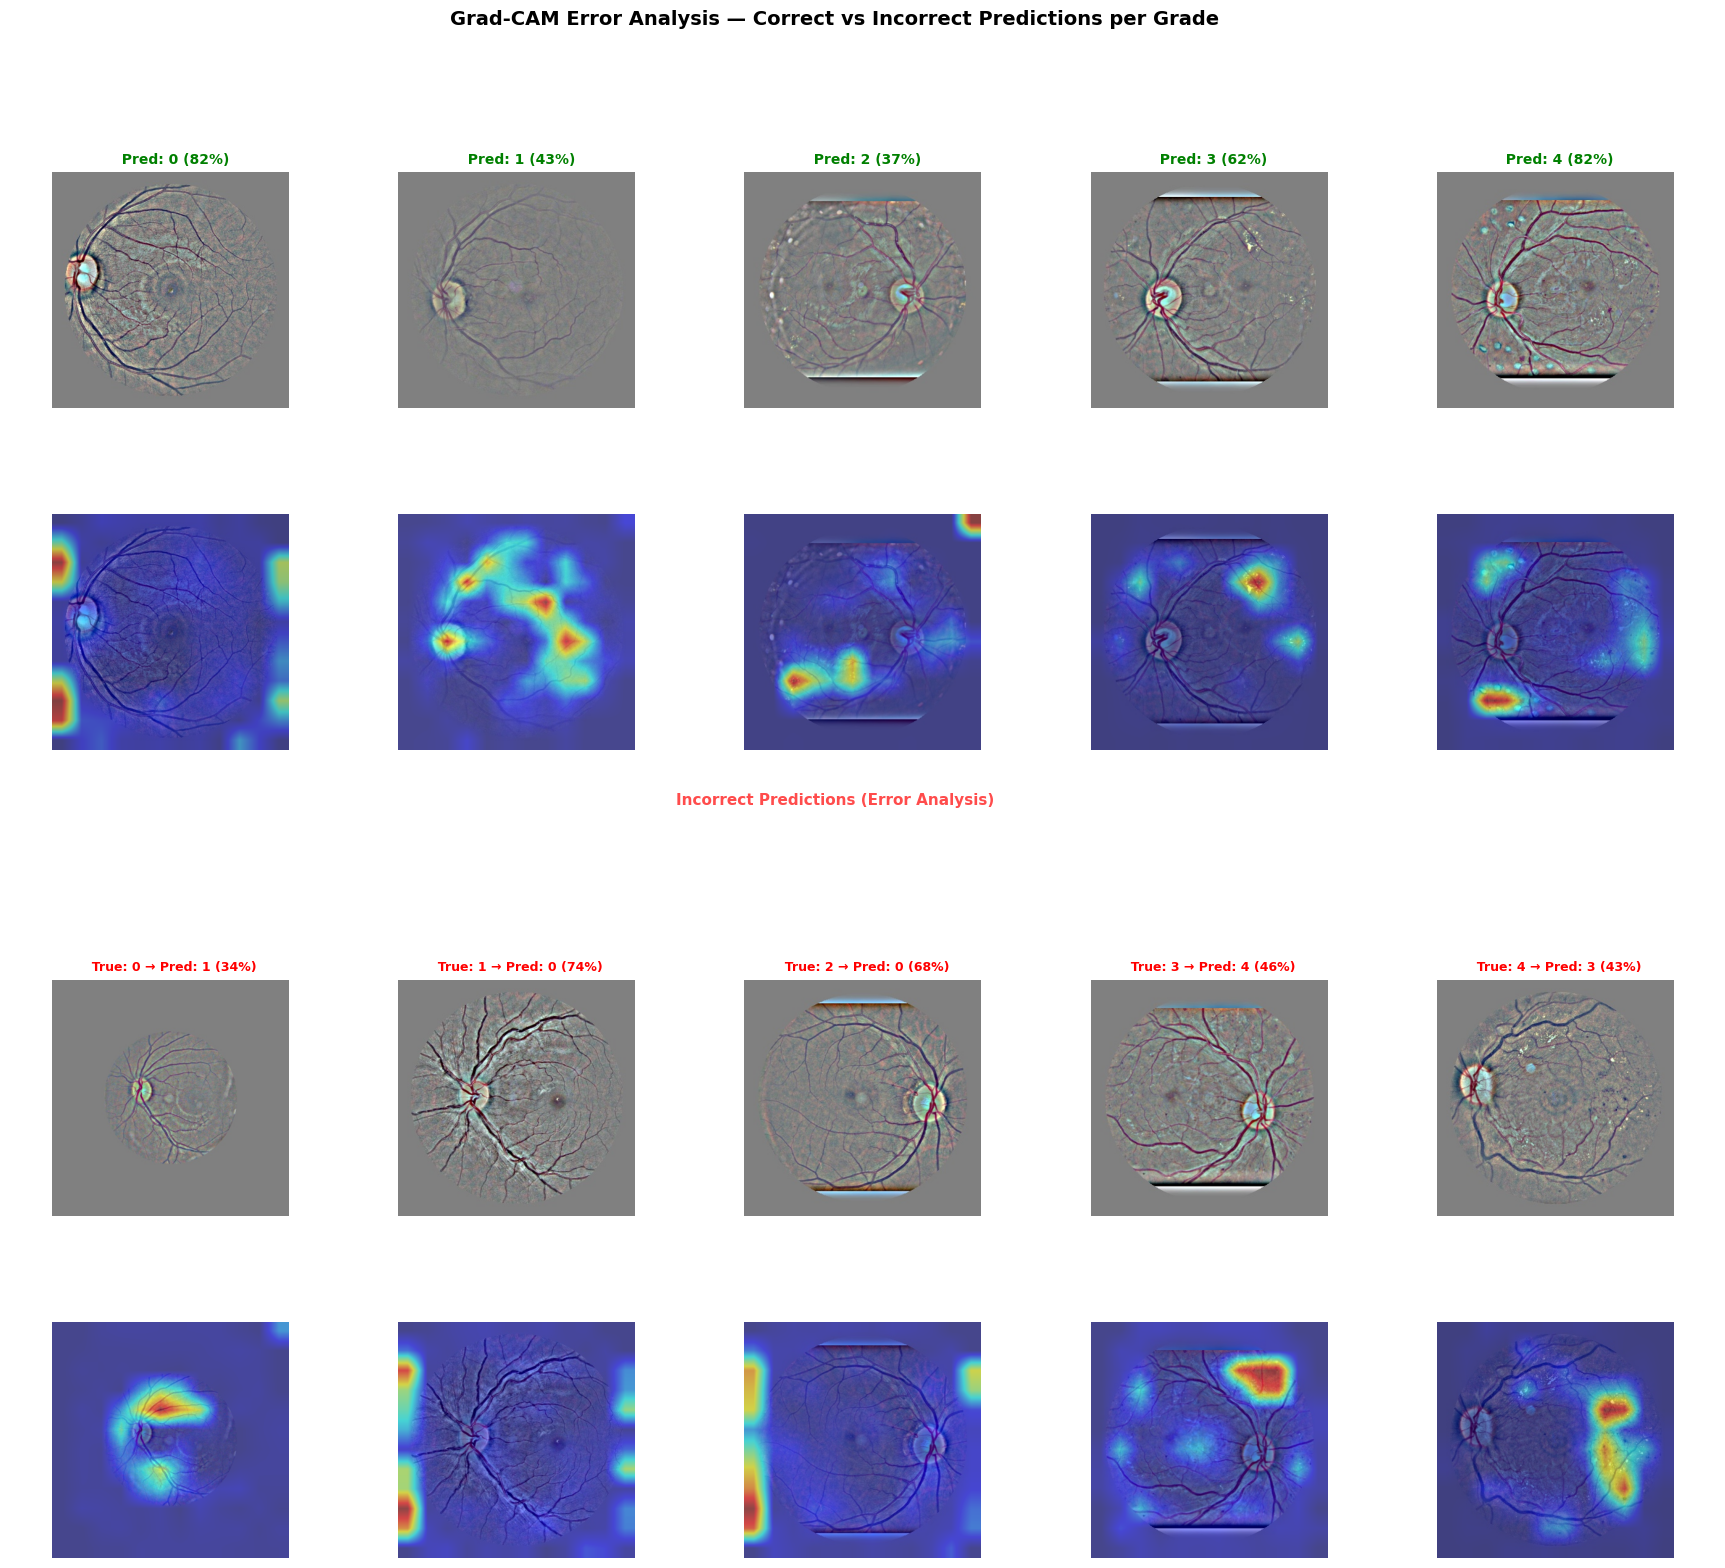

In [10]:
# Select last convolutional layer for Grad-CAM
target_layers = [model.features[-1]]

print("Running inference on test set for error analysis...")

model.eval()
sample_records = []   
# Limit number of samples per class for balance
MAX_PER_GRADE    = 5  
# Track correct and incorrect counts per grade
correct_counts   = {g: 0 for g in range(5)}
incorrect_counts = {g: 0 for g in range(5)}

# Scan test set and collect predictions
for idx in tqdm(range(len(test_df)), desc="Scanning test set"):
    true_label = int(test_df.iloc[idx]['level'])

    if (correct_counts[true_label]   >= MAX_PER_GRADE and
            incorrect_counts[true_label] >= MAX_PER_GRADE):
       
        if all(correct_counts[g]   >= MAX_PER_GRADE and
               incorrect_counts[g] >= MAX_PER_GRADE for g in range(5)):
            print(f"  Early exit at image {idx} — all grades have "
                  f"{MAX_PER_GRADE} correct + {MAX_PER_GRADE} incorrect candidates.")
            break
        continue  
    
    # Load image path
    img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
    img_path = os.path.join(TRAIN_IMG_DIR, img_name)

    # Load and resize image
    orig_img = Image.open(img_path).convert("RGB")
    orig_img = orig_img.resize((384, 384))

    # Normalize using ImageNet statistics
    tensor       = F.to_tensor(orig_img)
    tensor       = F.normalize(tensor,
                               mean=[0.485, 0.456, 0.406],
                               std =[0.229, 0.224, 0.225])
    input_tensor = tensor.unsqueeze(0).to(device)

    # Run inference without gradients
    with torch.no_grad():
        outputs    = model(input_tensor)
        pred_label = int(torch.argmax(outputs, dim=1).item())
        confidence = torch.softmax(outputs, dim=1)[0, pred_label].item()

    sample_records.append((idx, true_label, pred_label, confidence))

    if true_label == pred_label:
        correct_counts[true_label] += 1
    else:
        incorrect_counts[true_label] += 1

# Print summary of scanned samples
print(f"  Scanned {len(sample_records)} images total.")
print(f"  Correct   candidates per grade: {correct_counts}")
print(f"  Incorrect candidates per grade: {incorrect_counts}")

# Select one correct + one incorrect per class
correct   = {}   
incorrect = {}  

for record in sample_records:
    idx, true_label, pred_label, confidence = record
    # First correct prediction per class
    if true_label not in correct and true_label == pred_label:
        correct[true_label] = record
    # First incorrect prediction per class
    if true_label not in incorrect and true_label != pred_label:
        incorrect[true_label] = record
    if len(correct) == 5 and len(incorrect) == 5:
        break

# Check missing cases
for g in range(5):
    if g not in correct:
        print(f"  Warning: No correct prediction found for Grade {g}")
    if g not in incorrect:
        print(f"  Warning: No incorrect prediction found for Grade {g}")

# Function: Generate Grad-Cam Images
def render_gradcam_row(cam, records_dict, axes_row, row_label):

    for grade in range(5):
        ax = axes_row[grade]

        if grade not in records_dict:
            ax.text(0.5, 0.5, 'No sample\nfound', ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
            ax.axis('off')
            continue

        idx, true_label, pred_label, confidence = records_dict[grade]

        # Load image
        img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        orig_img = Image.open(img_path).convert("RGB")
        orig_img = orig_img.resize((384, 384))
        orig_np  = np.array(orig_img).astype(np.float32) / 255.0

        # Prepare tensor
        tensor       = F.to_tensor(orig_img)
        tensor       = F.normalize(tensor,
                                   mean=[0.485, 0.456, 0.406],
                                   std =[0.229, 0.224, 0.225])
        input_tensor = tensor.unsqueeze(0).to(device)

        # Generate Grad-CAM heatmap
        targets   = [ClassifierOutputTarget(pred_label)]
        grayscale = cam(input_tensor=input_tensor, targets=targets)
        heatmap   = show_cam_on_image(orig_np, grayscale[0], use_rgb=True)
        ax.imshow(heatmap)

        title_color = 'green' if true_label == pred_label else 'red'
        outcome     = 'Correct' if true_label == pred_label else 'Wrong'
        ax.set_title(f'{outcome}\nTrue: {true_label}  Pred: {pred_label} ({confidence:.0%})', fontsize=9, fontweight='bold', color=title_color)
        ax.axis('off')

    # Row label on the first axis
    axes_row[0].set_ylabel(row_label, fontsize=11, fontweight='bold')

fig = plt.figure(figsize=(22, 18))

gs = gridspec.GridSpec( 5, 5, figure=fig, height_ratios=[4, 4, 0.3, 4, 4], hspace=0.55, wspace=0.08)
# Axes for correct predictions
axes_correct_orig  = [fig.add_subplot(gs[0, c]) for c in range(5)]
axes_correct_cam   = [fig.add_subplot(gs[1, c]) for c in range(5)]
# Axes for incorrect predictions
axes_incorrect_orig = [fig.add_subplot(gs[3, c]) for c in range(5)]
axes_incorrect_cam  = [fig.add_subplot(gs[4, c]) for c in range(5)]

for c in range(5):
    ax_div = fig.add_subplot(gs[2, c])
    ax_div.set_facecolor('#CCCCCC')
    ax_div.axis('off')

# Class labels
grade_labels = ['Grade 0\n(Healthy)', 'Grade 1\n(Mild)','Grade 2\n(Moderate)', 'Grade 3\n(Severe)','Grade 4\n(Proliferative)']

for c, lbl in enumerate(grade_labels):
    axes_correct_orig[c].set_title(lbl, fontsize=10, fontweight='bold', color='#333333', pad=6)

# Section labels
axes_correct_orig[0].set_ylabel('Original\n(Correct)', fontsize=10,  fontweight='bold', color='green')
axes_correct_cam[0].set_ylabel('Grad-CAM\n(Correct)', fontsize=10,  fontweight='bold', color='green')
axes_incorrect_orig[0].set_ylabel('Original\n(Incorrect)', fontsize=10,  fontweight='bold', color='red')
axes_incorrect_cam[0].set_ylabel('Grad-CAM\n(Incorrect)', fontsize=10, fontweight='bold', color='red')


# Generate Grad-CAM visualizations
with GradCAM(model=model, target_layers=target_layers) as cam:

    # Correct predictions
    for grade in range(5):
        ax_orig = axes_correct_orig[grade]
        ax_cam  = axes_correct_cam[grade]

        if grade not in correct:
            for ax in [ax_orig, ax_cam]:
                ax.text(0.5, 0.5, 'No sample\nfound',  ha='center', va='center',  transform=ax.transAxes, fontsize=9, color='gray')
                ax.axis('off')
            continue

        idx, true_label, pred_label, confidence = correct[grade]

        # Load image
        img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        orig_img = Image.open(img_path).convert("RGB").resize((384, 384))
        orig_np  = np.array(orig_img).astype(np.float32) / 255.0

        # Preprocess
        tensor       = F.to_tensor(orig_img)
        tensor       = F.normalize(tensor, mean=[0.485, 0.456, 0.406],
                                           std =[0.229, 0.224, 0.225])
        input_tensor = tensor.unsqueeze(0).to(device)

        # Grad-CAM
        targets   = [ClassifierOutputTarget(pred_label)]
        grayscale = cam(input_tensor=input_tensor, targets=targets)
        heatmap   = show_cam_on_image(orig_np, grayscale[0], use_rgb=True)

        ax_orig.imshow(orig_np)
        ax_orig.set_title(f'  Pred: {pred_label} ({confidence:.0%})', fontsize=10, fontweight='bold', color='green')
        ax_orig.axis('off')
        ax_cam.imshow(heatmap)
        ax_cam.axis('off')

    # Incorrect predictions
    for grade in range(5):
        ax_orig = axes_incorrect_orig[grade]
        ax_cam  = axes_incorrect_cam[grade]

        if grade not in incorrect:
            for ax in [ax_orig, ax_cam]:
                ax.text(0.5, 0.5, 'No sample\nfound',  ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
                ax.axis('off')
            continue

        idx, true_label, pred_label, confidence = incorrect[grade]
        
        # Load image
        img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        orig_img = Image.open(img_path).convert("RGB").resize((384, 384))
        orig_np  = np.array(orig_img).astype(np.float32) / 255.0
        
        # Preprocess
        tensor       = F.to_tensor(orig_img)
        tensor       = F.normalize(tensor, mean=[0.485, 0.456, 0.406],
                                           std =[0.229, 0.224, 0.225])
        input_tensor = tensor.unsqueeze(0).to(device)

        # Grad-CAM
        targets   = [ClassifierOutputTarget(pred_label)]
        grayscale = cam(input_tensor=input_tensor, targets=targets)
        heatmap   = show_cam_on_image(orig_np, grayscale[0], use_rgb=True)

        ax_orig.imshow(orig_np)
        ax_orig.set_title(f'  True: {true_label} → Pred: {pred_label} ({confidence:.0%})',  fontsize=9, fontweight='bold', color='red')
        ax_orig.axis('off')
        ax_cam.imshow(heatmap)
        ax_cam.axis('off')

# Overall titles
fig.text(0.5, 0.97, 'Grad-CAM Error Analysis — Correct vs Incorrect Predictions per Grade', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text(0.5, 0.535, 'Incorrect Predictions (Error Analysis)', ha='center', va='top', fontsize=11, fontweight='bold', color='red', alpha=0.7)
plt.tight_layout()
plt.show()

> Interpretation:
>
> - EfficientNet-B4 exhibits a more scattered and fine-grained attention pattern.
>   
> - In correct predictions, particularly for Grades 1 and 3, the model focuses on small, localized regions. This reflects its ability to detect fine textures and subtle features such as microaneurysms, which is likely a result of its ImageNet pretraining.
>
> - At the same time, this behaviour introduces certain weaknesses. In some incorrect predictions, the model focuses on the edges of the image rather than the retinal region itself. This suggests that it may confuse imaging artifacts, such as uneven lighting or noise, with actual medical features.
>
> - For Grade 4 cases, the model shows strong activation across multiple regions of the retina. This aligns with its strong performance on severe cases, as proliferative diabetic retinopathy typically presents with widespread and visually distinct abnormalities.
>
> **EfficientNet-B4 focuses on small, localized features due to its general-purpose feature extraction, making it effective at detecting fine details but also more sensitive to noise and artifacts.**
>
> **In terms of failure modes, EfficientNet tends to be distracted by edge artifacts, suggesting that improvements such as tighter cropping around the retina could enhance performance.**
---

####  <font color = blue> **VI. Reliability Diagram Analysis** </font>

Reliability diagrams are used to evaluate model calibration, which measures how well predicted probabilities reflect actual outcomes. In a well-calibrated model, predictions should closely match real-world frequencies. This is represented by the diagonal line in the diagram, where perfect calibration lies. The closer the model’s curve is to this line, the more reliable its probability.

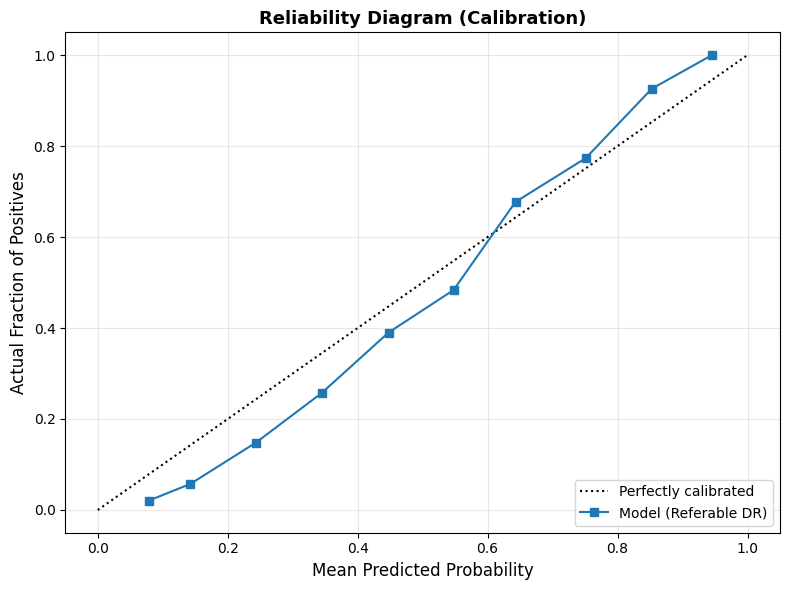

In [11]:
def plot_calibration_curve(all_labels_eval, all_probs):

    # Convert inputs to NumPy arrays for easier processing
    all_probs = np.array(all_probs)
    all_labels_eval = np.array(all_labels_eval)

    # Check that predictions and labels have the same length
    assert len(all_labels_eval) == len(all_probs), (
        f"Length mismatch: all_labels_eval has {len(all_labels_eval)} samples "
        f"but all_probs has {len(all_probs)} samples. "
        f"Make sure both come from the same evaluation loop."
    )

    plt.figure(figsize=(8, 6))
    # Plot perfectly calibrated reference line (ideal model)
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

    # Convert multi-class problem into binary classification:
    # Class 0–1 = non-referable, Class 2–4 = referable DR
    bin_labels      = (all_labels_eval >= 2).astype(int)

    referable_probs = all_probs[:, 2:].sum(axis=1)

    # Compute calibration curve (reliability diagram data)
    prob_true, prob_pred = calibration_curve(bin_labels, referable_probs, n_bins=10)

    # Plot model calibration curve
    plt.plot(prob_pred, prob_true, "s-", label="Model (Referable DR)")
    
    plt.ylabel("Actual Fraction of Positives", fontsize=12)
    plt.xlabel("Mean Predicted Probability", fontsize=12)
    plt.title('Reliability Diagram (Calibration)', fontsize=13, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_calibration_curve(all_labels_eval, all_probs);

> Intepretation:
>
> - For EfficientNet-B4, the reliability curve lies mostly below the diagonal line, particularly in the lower probability range (0.0–0.5).
> 
> - This indicates overconfidence, meaning the model tends to assign higher probabilities than what is observed in reality. For example, when the model predicts a 40% chance of disease, the true occurrence may be closer to 30%.
>
> - From a clinical perspective, this behaviour can lead to overestimation of risk in borderline cases. As a result, it may produce more false positives.
>
---

### </font> <font color = #41EA46> **5: Prevalence Alignment Analysis**</font>

A prevalence alignment analysis was conducted to evaluate the models’ suitability for clinical deployment. This approach goes beyond standard validation metrics by examining how the models behave when applied to a large, real-world dataset. In this case, EfficientNet-B4 model was used to generate predictions for an unlabeled dataset containing approximately 53,000 retinal images (around 53GB in total). The predicted class distributions from this dataset were then compared against the known distribution of the training data. This comparison helps identify systemic bias in the models.

**External Inference Pipeline:** This section describes the final inference pipeline used to generate predictions on unseen test images and store results for downstream analysis.

In [12]:
# Set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inference preprocessing function
# Ensures test images are processed exactly like training images
def preprocess_for_inference(image):
    # Resize image to match model input size
    image = F.resize(image, [384, 384])
    image = F.to_tensor(image)
    # Normalize using ImageNet mean and std (must match training pipeline)
    image = F.normalize(image,
                        mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
    return image

# Load trained model for inference
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.eval()
results = []

# Get all JPEG images from holdout test directory
image_files = [f for f in os.listdir(UNLABELED_TEST_DIR) if f.lower().endswith('.jpeg')]

# Run inference on unseen test images
with torch.no_grad():
    for img_name in tqdm(image_files, desc="Predicting External Inference Set Images"):
        img_path = os.path.join(UNLABELED_TEST_DIR, img_name)
        image = Image.open(img_path).convert("RGB")
        # Preprocess image and add batch dimension
        img_tensor = preprocess_for_inference(image).unsqueeze(0).to(device)
        outputs = model(img_tensor)
        # Get predicted class (highest probability)
        predicted_grade = int(torch.argmax(outputs, dim=1).item())
        confidence      = torch.softmax(outputs, dim=1)[0, predicted_grade].item() 

        # Store prediction result
        results.append({'image': img_name, 'confidence': round(confidence, 4), 'predicted_level': predicted_grade})

# Save predictions to CSV file
df_preds = pd.DataFrame(results)
df_preds.to_csv(SAVE_PREDICTIONS_PATH, index=False)

Predicting Test Holdout Images: 100%|██████████| 53576/53576 [32:34<00:00, 27.41it/s]


**Training vs. Model Prediction Distribution Analysis:** This section compares the true class distribution in the training dataset with the distribution of model predictions on the unseen holdout set. The below charts present a side-by-side comparison of two distributions: the actual class distribution in the training dataset (left panel) and the distribution of predictions generated by each model on the unlabelled test set (right panel). This type of visualization is a well-established diagnostic tool in medical AI research for identifying majority class bias. Ideally, a well-calibrated model should produce a prediction distribution that closely reflects the true underlying class distribution.

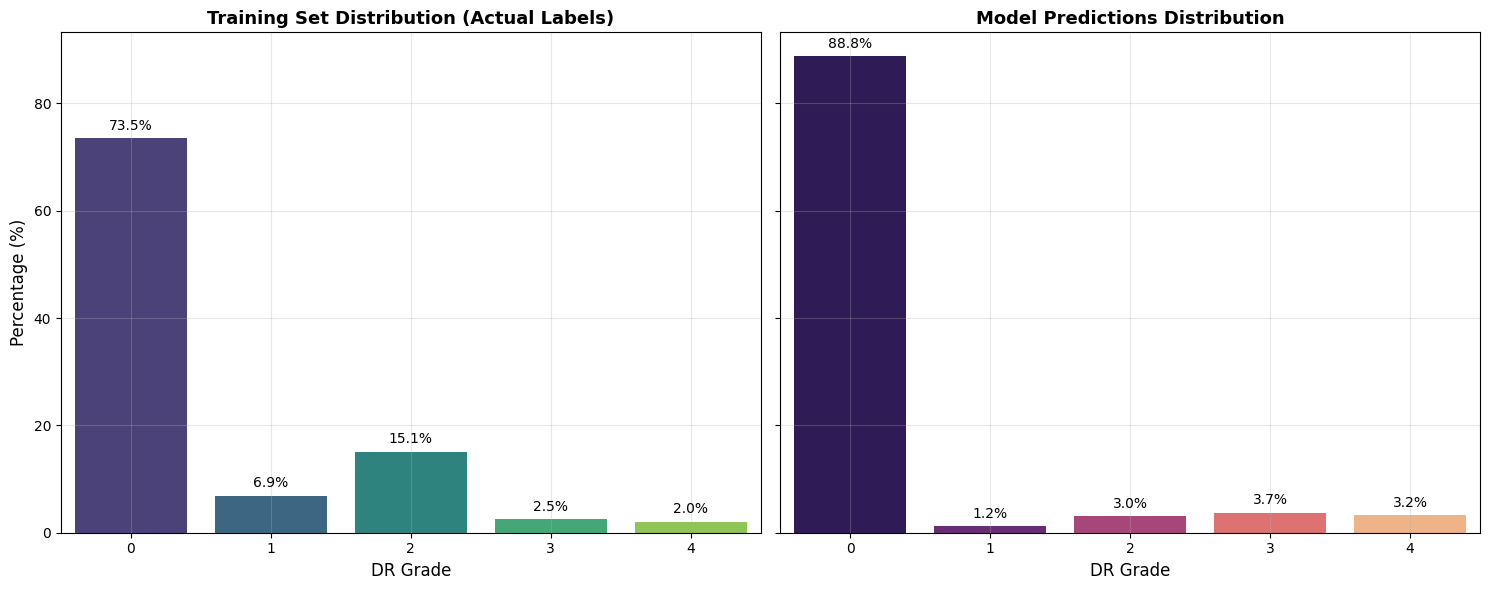

In [13]:
# Load saved model predictions from CSV file
predictions_df = pd.read_csv(SAVE_PREDICTIONS_PATH)

def plot_distribution_comparison(train_df, predictions_df):
    
    # Calculate training set class distribution (percentage)
    train_dist = train_df['level'].value_counts(normalize=True).sort_index() * 100
    # Calculate prediction distribution (percentage) 
    predictions_dist = predictions_df['predicted_level'].value_counts(normalize=True).sort_index() * 100

    # Ensure all classes (0–4) exist in both distributions
    grades = [0, 1, 2, 3, 4]
    train_dist = train_dist.reindex(grades, fill_value=0)
    predictions_dist = predictions_dist.reindex(grades, fill_value=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # Training set distribution
    sns.barplot(x=train_dist.index, y=train_dist.values, ax=ax1, palette="viridis")
    ax1.set_title('Training Set Distribution (Actual Labels)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('DR Grade', fontsize=12)
    ax1.set_ylabel('Percentage (%)', fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Prediction distribution
    sns.barplot(x=predictions_dist.index, y=predictions_dist.values, ax=ax2, palette="magma")
    ax2.set_title('Model Predictions Distribution', fontsize=13, fontweight='bold')
    ax2.set_xlabel('DR Grade', fontsize=12)
    ax2.set_ylabel('Percentage (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)

    # Add percentage labels on bars
    for ax in [ax1, ax2]:
        for p in ax.patches:
            ax.annotate( f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center',
                        xytext=(0, 9), textcoords='offset points', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_distribution_comparison(train_df, predictions_df);

> Interpretation:
>
> - EfficientNet predicts Grade 0 for 88.8% of all test images, which is 15.3 percentage points higher than the true training prevalence of 73.5%. This indicates a strong majority class bias.
>
> - The impact on minority classes is substantial. Grade 1 predictions drop from 6.9% to just 1.2%, representing a reduction of approximately 83% relative to its true frequency. Grade 2 shows a similar pattern, decreasing from 15.1% to 3.0%.
>
> - The only classes where predictions approach or slightly exceed true prevalence are Grades 3 and 4. This aligns with earlier findings showing that EfficientNet performs best on severe and proliferative DR. In effect, the model has learned to detect visually obvious, high-severity cases while classifying many less obvious diseased cases as healthy.
>
---

**Prediction Distribution Bias and Its Clinical Interpretation (EfficientNet)**

The analysis of prediction distributions shows a consistent pattern where the model predicts Grade 0 (Healthy) at a higher rate than its actual occurrence in the dataset. At the same time, Grade 1 (Mild) is significantly under-predicted. This behaviour is not unique to this model but is a well-recognised outcome in medical deep learning, especially for diabetic retinopathy grading tasks that exhibit strong class imbalance.

**Grade 0 Over-Prediction and Grade 1 Under-Prediction:** The model demonstrates a clear tendency to favor the Healthy (Grade 0) class when uncertainty is present. This leads to frequent misclassification of early disease stages (Grades 1 and 2) as normal cases. In some cases, even more advanced grades are occasionally shifted toward lower severity predictions.

This occurs primarily because the dataset is heavily skewed toward Grade 0, meaning the model is exposed to a much larger number of healthy examples during training. As a result, it develops a stronger decision boundary around the healthy class, making it the “default prediction” when features are ambiguous.

Grade 1 is the most affected category. It shows the lowest detection reliability because:

- It has limited representation in the dataset
- Its visual features are very close to Grade 0
- The model struggles to distinguish subtle microvascular changes

When uncertainty arises between Grade 0 and Grade 1, the model consistently favors Grade 0 due to the stronger learned prior.

**Limitations of Imbalance Mitigation Techniques:** Although techniques such as weighted loss functions, focal loss, and sampling strategies are applied during training, they do not completely eliminate prediction bias. These methods improve learning efficiency within training batches but do not change the underlying real-world distribution the model encounters during inference.

As a result, when deployed or tested on naturally imbalanced data, the model tends to revert to predicting the dominant class (Grade 0), especially in ambiguous cases. This indicates that the learned decision boundaries still reflect the original data imbalance to some extent.

**Effect of Real-World Prevalence Shift:** A key factor influencing this behaviour is the difference between training distribution and real-world prevalence. In clinical settings, healthy cases significantly outnumber diseased cases. This creates a prevalence shift, where the model must operate under conditions that differ from its training environment.

While training strategies can partially reduce imbalance effects, they cannot fully account for this shift. Consequently, models trained on imbalanced datasets often show reduced sensitivity to minority classes when deployed in real-world scenarios.

This explains why the EfficientNet-based model tends to over-predict Grade 0 and under-predict early-stage disease.

**Clinical Interpretation:** From a clinical perspective, this behaviour has important implications. The model is highly effective as a screening tool for identifying healthy cases, but it is less reliable for detecting early-stage diabetic retinopathy. This trade-off is typical in imbalanced medical classification tasks, where improving sensitivity for rare conditions often requires additional calibration or targeted feature enhancement.

Overall, the observed prediction bias reflects a known limitation of deep learning models trained on imbalanced medical datasets rather than a failure of the EfficientNet architecture itself.

---